<a href="https://colab.research.google.com/github/yanchenliu-cxk/ESM/blob/main/esm_2_6_5b_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch biopython accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.7 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, EsmModel
from Bio import SeqIO
import numpy as np

# 1. 设置计算设备 (调用 T4 GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用的计算设备: {device}")

# 2. 从 Hugging Face 加载 6.5 亿参数的 ESM-2 模型和分词器
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name).to(device)
model.eval() # 设置为评估模式

# 3. 读取之前上传的 FASTA 文件
fasta_file = "/content/Galaxy36-[clean Prodigal protein].fasta" # 请确保文件名与你上传的一致
protein_sequences = []

for record in SeqIO.parse(fasta_file, "fasta"):
    protein_sequences.append(str(record.seq))

print(f"成功读取 {len(protein_sequences)} 条序列。")

# 4. 批量提取高维特征向量 (Embeddings)
batch_size = 2 # 免费 T4 显存有限，每次处理 2 条
all_embeddings = []

with torch.no_grad():
    for i in range(0, len(protein_sequences), batch_size):
        batch_seqs = protein_sequences[i:i+batch_size]

        # 序列词元化与截断
        inputs = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # 模型前向推理
        outputs = model(**inputs)
        last_hidden_states = outputs.last_hidden_state

        # 均值池化 (Mean-pooling)：屏蔽掉 padding 部分，将残基特征压缩为全局特征
        attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden_states.size()).float()
        sum_embeddings = torch.sum(last_hidden_states * attention_mask, 1)
        sum_mask = attention_mask.sum(1)
        sum_mask = torch.clamp(sum_mask, min=1e-9)
        mean_pooled = sum_embeddings / sum_mask

        # 将特征向量转移到 CPU 内存并保存
        all_embeddings.extend(mean_pooled.cpu().numpy())

        # 打印进度
        if (i + batch_size) % 100 == 0 or (i + batch_size) >= len(protein_sequences):
            print(f"已处理 {min(i + batch_size, len(protein_sequences))} / {len(protein_sequences)} 条序列...")

# 5. 保存特征结果为 NumPy 矩阵文件
embeddings_matrix = np.array(all_embeddings)
np.save("nocardioides_esm2_650M_embeddings.npy", embeddings_matrix)

print(f"提取完成！特征矩阵维度为: {embeddings_matrix.shape} (预期为 序列总数 x 1280)")

当前使用的计算设备: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


成功读取 5252 条序列。
已处理 100 / 5252 条序列...
已处理 200 / 5252 条序列...
已处理 300 / 5252 条序列...
已处理 400 / 5252 条序列...
已处理 500 / 5252 条序列...
已处理 600 / 5252 条序列...
已处理 700 / 5252 条序列...
已处理 800 / 5252 条序列...
已处理 900 / 5252 条序列...
已处理 1000 / 5252 条序列...
已处理 1100 / 5252 条序列...
已处理 1200 / 5252 条序列...
已处理 1300 / 5252 条序列...
已处理 1400 / 5252 条序列...
已处理 1500 / 5252 条序列...
已处理 1600 / 5252 条序列...
已处理 1700 / 5252 条序列...
已处理 1800 / 5252 条序列...
已处理 1900 / 5252 条序列...
已处理 2000 / 5252 条序列...
已处理 2100 / 5252 条序列...
已处理 2200 / 5252 条序列...
已处理 2300 / 5252 条序列...
已处理 2400 / 5252 条序列...
已处理 2500 / 5252 条序列...
已处理 2600 / 5252 条序列...
已处理 2700 / 5252 条序列...
已处理 2800 / 5252 条序列...
已处理 2900 / 5252 条序列...
已处理 3000 / 5252 条序列...
已处理 3100 / 5252 条序列...
已处理 3200 / 5252 条序列...
已处理 3300 / 5252 条序列...
已处理 3400 / 5252 条序列...
已处理 3500 / 5252 条序列...
已处理 3600 / 5252 条序列...
已处理 3700 / 5252 条序列...
已处理 3800 / 5252 条序列...
已处理 3900 / 5252 条序列...
已处理 4000 / 5252 条序列...
已处理 4100 / 5252 条序列...
已处理 4200 / 5252 条序列...
已处理 4300 / 5252 条序列...
已处理 4

In [ ]:
!pip install umap-learn

Original embeddings_matrix shape: (5252, 1280)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embeddings shape: (5252, 2)


/tmp/ipykernel_2394/2679454641.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


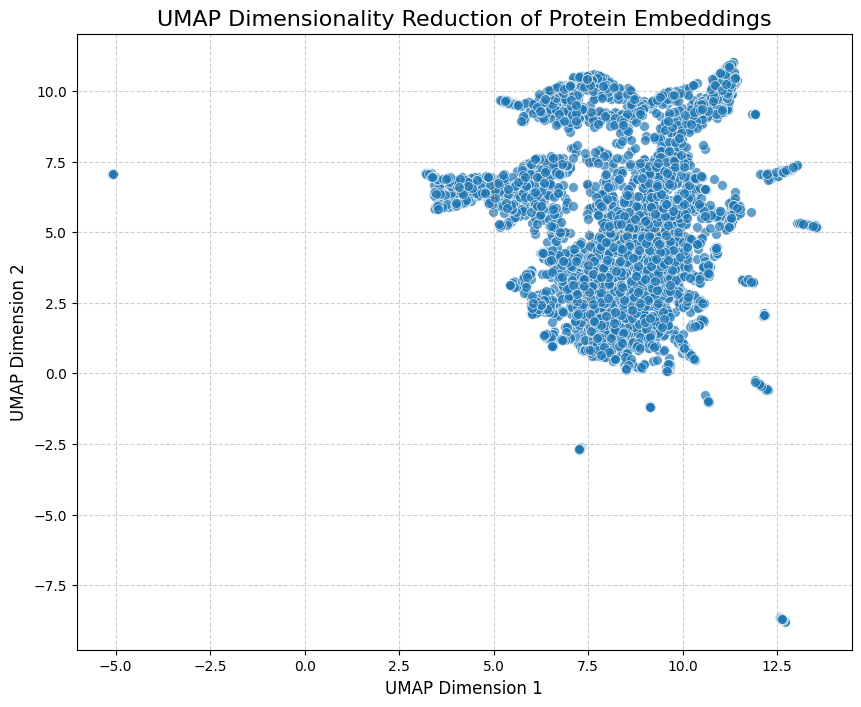

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 使用 UMAP 进行降维
# 可以根据数据量和需求调整 n_neighbors 和 min_dist 参数
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
# 确保 embeddings_matrix 已经从上一步生成并可用
if 'embeddings_matrix' not in locals():
    print("Error: embeddings_matrix not found. Please run the previous cell first.")
else:
    print(f"Original embeddings_matrix shape: {embeddings_matrix.shape}")
    # Convert numpy array to float32 if not already to avoid potential UMAP warnings
    embeddings_matrix_float32 = embeddings_matrix.astype('float32')
    reduced_embeddings = reducer.fit_transform(embeddings_matrix_float32)
    print(f"Reduced embeddings shape: {reduced_embeddings.shape}")

    # 2. 可视化降维结果
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=reduced_embeddings[:, 0],
        y=reduced_embeddings[:, 1],
        # hue=labels, # 如果有类别标签，可以取消注释并传入标签
        palette='viridis', # 配色方案
        s=50, # 点的大小
        alpha=0.7 # 点的透明度
    )
    plt.title('UMAP Dimensionality Reduction of Protein Embeddings', fontsize=16)
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Original embeddings_matrix_float32 shape: (5252, 1280)
t-SNE reduced embeddings shape: (5252, 2)


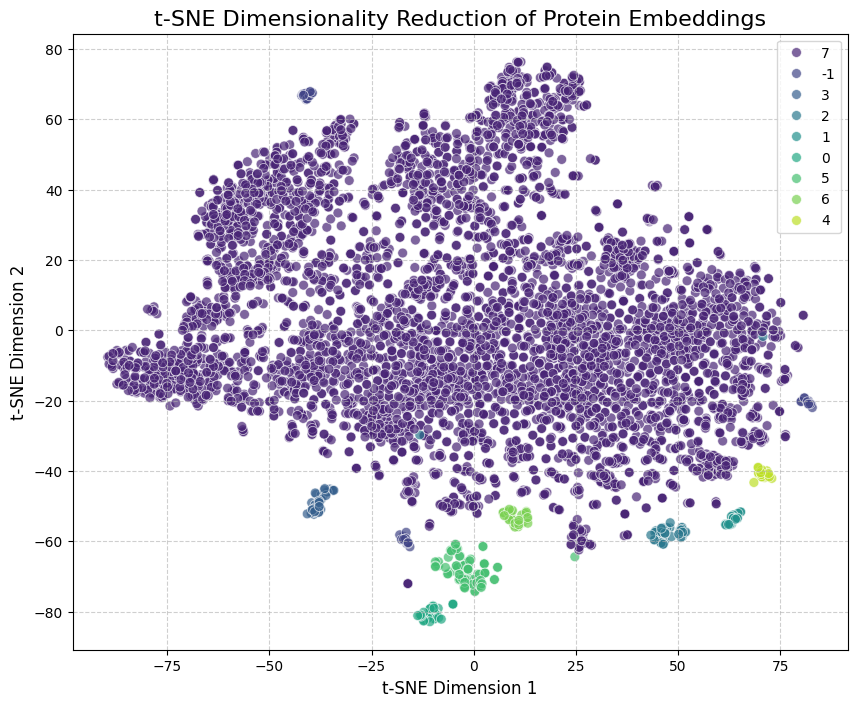

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 使用 t-SNE 进行降维
# 注意：t-SNE 的计算成本较高，对于大型数据集可能需要较长时间。
# 建议先对小样本进行测试，或调整 perplexity 和 learning_rate 等参数。

# 确保 embeddings_matrix_float32 已经从上一步生成并可用
if 'embeddings_matrix_float32' not in locals():
    print("Error: embeddings_matrix_float32 not found. Please run the ESM-2 and UMAP cells first.")
else:
    print(f"Original embeddings_matrix_float32 shape: {embeddings_matrix_float32.shape}")

    # 初始化 t-SNE 模型，n_components=2 表示降维到二维
    # perplexity 通常在 5 到 50 之间，learning_rate 建议在 10 到 1000 之间
    # 将 n_iter 修改为 max_iter 以适应最新版本的 scikit-learn
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42, n_jobs=-1)
    tsne_embeddings = tsne.fit_transform(embeddings_matrix_float32)
    print(f"t-SNE reduced embeddings shape: {tsne_embeddings.shape}")

    # 2. 可视化 t-SNE 降维结果
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=tsne_embeddings[:, 0],
        y=tsne_embeddings[:, 1],
        hue=cluster_labels.astype(str), # 如果希望在 t-SNE 图上显示之前的 HDBSCAN 聚类结果，可以取消注释
        palette='viridis', # 配色方案
        s=50, # 点的大小
        alpha=0.7 # 点的透明度
    )
    plt.title('t-SNE Dimensionality Reduction of Protein Embeddings', fontsize=16)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### Visualize Cluster Characteristics with a Heatmap

To understand the distinct features of each cluster, we can visualize the average (mean) embedding for each cluster using a heatmap. This helps in identifying which dimensions of the protein embeddings are more prominent in certain clusters.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure cluster_labels and embeddings_matrix_float32 are available
if 'cluster_labels' not in locals() or 'embeddings_matrix_float32' not in locals():
    print("Error: 'cluster_labels' or 'embeddings_matrix_float32' not found. Please run previous cells.")
else:
    # Create a DataFrame for easier grouping
    embeddings_df = pd.DataFrame(embeddings_matrix_float32)
    embeddings_df['cluster'] = cluster_labels

    # Filter out noise points (-1 cluster label)
    clustered_embeddings_df = embeddings_df[embeddings_df['cluster'] != -1]

    if not clustered_embeddings_df.empty:
        # Calculate the mean embedding for each cluster
        mean_embeddings_per_cluster = clustered_embeddings_df.groupby('cluster').mean()

        # Visualize the mean embeddings as a heatmap
        plt.figure(figsize=(15, 8))
        sns.heatmap(
            mean_embeddings_per_cluster,
            cmap='viridis',
            cbar_kws={'label': 'Mean Embedding Value'},
            linecolor='white',
            linewidths=0.5
        )
        plt.title('Heatmap of Mean Protein Embeddings Per Cluster', fontsize=16)
        plt.xlabel('Embedding Dimension', fontsize=12)
        plt.ylabel('Cluster Label', fontsize=12)
        plt.show()
    else:
        print("No clustered points found after filtering out noise. Cannot create heatmap.")

Error: 'cluster_labels' or 'embeddings_matrix_float32' not found. Please run previous cells.


In [ ]:
import hdbscan
import numpy as np

# Ensure reduced_embeddings is available for HDBSCAN
# This code block assumes that 'reduced_embeddings' from the UMAP step is available.
# If you run cells out of order, please ensure 'reduced_embeddings' is defined.
if 'reduced_embeddings' not in locals():
    print("Error: 'reduced_embeddings' not found. Please run the UMAP cell first.")
else:
    # Use HDBSCAN for clustering
    # You can adjust min_cluster_size and min_samples parameters as needed
    clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=10, cluster_selection_epsilon=0.1, gen_min_span_tree=True)
    cluster_labels = clusterer.fit_predict(reduced_embeddings)

    # Get the number of clusters (ignoring -1, which indicates noise points)
    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"HDBSCAN identified {num_clusters} clusters and {np.sum(cluster_labels == -1)} noise points.")
    print("The 'cluster_labels' variable has been generated.")

Error: 'reduced_embeddings' not found. Please run the UMAP cell first.


In [ ]:
!pip install hdbscan

In [ ]:
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 使用 HDBSCAN 进行聚类
# 可以根据数据和需求调整 min_cluster_size 和 min_samples 参数
# 如果 reduced_embeddings 变量不存在，则会跳过此步骤
if 'reduced_embeddings' not in locals():
    print("Error: reduced_embeddings not found. Please run the UMAP cell first.")
else:
    # 调整 min_cluster_size 和 min_samples 参数
    clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=10, cluster_selection_epsilon=0.1, gen_min_span_tree=True)
    cluster_labels = clusterer.fit_predict(reduced_embeddings)

    # 获取聚类的数量 (忽略 -1，因为 -1 表示噪声点)
    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"HDBSCAN 识别到 {num_clusters} 个聚类，以及 {np.sum(cluster_labels == -1)} 个噪声点。")

    # 2. 可视化聚类结果
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=reduced_embeddings[:, 0],
        y=reduced_embeddings[:, 1],
        hue=cluster_labels.astype(str), # 将标签转换为字符串，以便 Seaborn 正确处理
        palette='viridis', # 配色方案
        s=50, # 点的大小
        alpha=0.7 # 点的透明度
    )
    plt.title('HDBSCAN Clustering of UMAP Reduced Protein Embeddings', fontsize=16)
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Error: reduced_embeddings not found. Please run the UMAP cell first.


In [ ]:
import numpy as np

# Ensure cluster_labels is available
if 'cluster_labels' not in locals():
    print("Error: 'cluster_labels' not found. Please run the HDBSCAN clustering cell first.")
else:
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    print("Cluster Label Distribution:")
    for label, count in zip(unique_labels, counts):
        if label == -1:
            print(f"  Noise Points (-1): {count} samples")
        else:
            print(f"  Cluster {label}: {count} samples")

Error: 'cluster_labels' not found. Please run the HDBSCAN clustering cell first.
